# From Linear to Logistic Regression via Gradient Descent

**Topics:**
1. Linear Regression with Closed-Form Solution
2. Gradient Descent vs SGD
3. Logistic Regression Introduction

---

In [10]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
print('✓ Ready')

✓ Ready


---
## Part 1: Linear Regression - Closed-Form Solution

**Goal:** Predict continuous values using a linear model

**The Model:** $\hat{y} = \theta_0 + \theta_1 x$

**Normal Equation (Closed-Form):**
$$\theta = (X^T X)^{-1} X^T y$$

 **Pros:** Exact solution, no hyperparameters  
 **Cons:** Slow for large datasets (matrix inversion is $O(n^3)$)

In [11]:
# Generate data: y = 2.5x + 3 + noise
X_train = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_train = 2.5 * X_train.flatten() + 3 + np.random.randn(10) * 2

# Add bias term (column of ones) to X
X_b = np.c_[np.ones((len(X_train), 1)), X_train]

# Closed-form solution
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train

print(f"Optimal parameters:")
print(f"  θ₀ (intercept) = {theta_normal[0]:.3f}")
print(f"  θ₁ (slope)     = {theta_normal[1]:.3f}")
print(f"  True: θ₀=3, θ₁=2.5")

Optimal parameters:
  θ₀ (intercept) = 3.972
  θ₁ (slope)     = 2.486
  True: θ₀=3, θ₁=2.5


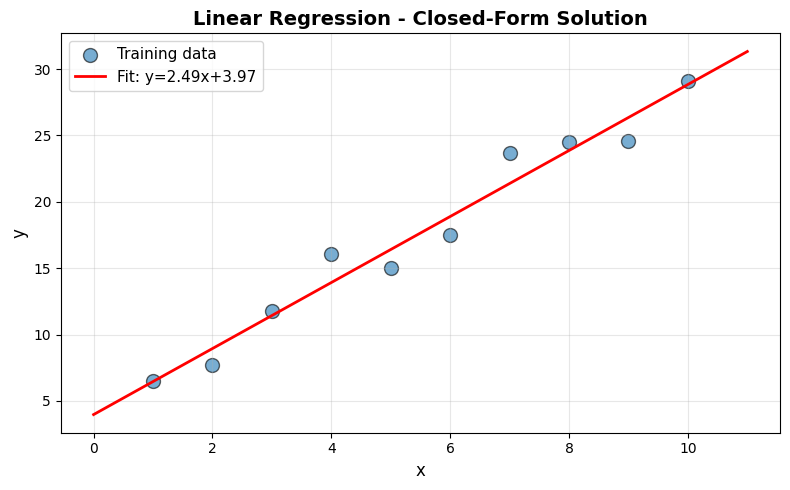

In [3]:
# Visualization
X_plot = np.linspace(0, 11, 100).reshape(-1, 1)
X_plot_b = np.c_[np.ones((len(X_plot), 1)), X_plot]
y_pred = X_plot_b @ theta_normal

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=100, alpha=0.6, edgecolors='k', label='Training data')
plt.plot(X_plot, y_pred, 'r-', linewidth=2, label=f'Fit: y={theta_normal[1]:.2f}x+{theta_normal[0]:.2f}')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Linear Regression - Closed-Form Solution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2: (Batch) Gradient Descent vs Stochastic Gradient Descent

**Alternative approach:** Iteratively minimize the cost function

**Cost Function (MSE):** $J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$

### (Batch) Gradient Descent (GD)
- Uses **ALL** training examples to compute gradient
- Update rule: $\theta := \theta - \alpha \nabla J(\theta)$
- Smooth convergence, but slow for large datasets

### Stochastic Gradient Descent (SGD)
- Uses **ONE** random example per update
- Much faster, but noisier convergence
- Better for large datasets and online learning

In [12]:
def compute_mse(X_b, y, theta):
    """Mean Squared Error"""
    m = len(y)
    predictions = X_b @ theta
    return (1/m) * np.sum((predictions - y)**2)

def gradient_descent(X_b, y, learning_rate=0.01, n_iterations=50):
    """Batch Gradient Descent"""
    m = len(y)
    theta = np.random.randn(2)
    theta_history = [theta.copy()]
    cost_history = [compute_mse(X_b, y, theta)]
    
    for iteration in range(n_iterations):
        # Compute gradient using ALL examples
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        theta = theta - learning_rate * gradients
        theta_history.append(theta.copy())
        cost_history.append(compute_mse(X_b, y, theta))
    
    return theta, np.array(theta_history), np.array(cost_history)

def stochastic_gradient_descent(X_b, y, learning_rate=0.01, n_epochs=50):
    """Stochastic Gradient Descent"""
    m = len(y)
    theta = np.random.randn(2)
    theta_history = [theta.copy()]
    cost_history = [compute_mse(X_b, y, theta)]
    
    for epoch in range(n_epochs):
        for i in range(m):
            # Pick ONE random example
            random_index = np.random.randint(m)
            xi = X_b[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T @ (xi @ theta - yi)
            theta = theta - learning_rate * gradients
            theta_history.append(theta.copy())
            cost_history.append(compute_mse(X_b, y, theta))
    
    return theta, np.array(theta_history), np.array(cost_history)

print('✓ Functions defined')

✓ Functions defined


In [13]:
# Run both algorithms
theta_gd, theta_hist_gd, cost_hist_gd = gradient_descent(
    X_b, y_train, learning_rate=0.01, n_iterations=50)

theta_sgd, theta_hist_sgd, cost_hist_sgd = stochastic_gradient_descent(
    X_b, y_train, learning_rate=0.01, n_epochs=50)

print("Results comparison:")
print(f"\nNormal Equation: θ₀={theta_normal[0]:.3f}, θ₁={theta_normal[1]:.3f}")
print(f"GD:              θ₀={theta_gd[0]:.3f}, θ₁={theta_gd[1]:.3f} (cost: {cost_hist_gd[-1]:.3f})")
print(f"SGD:             θ₀={theta_sgd[0]:.3f}, θ₁={theta_sgd[1]:.3f} (cost: {cost_hist_sgd[-1]:.3f})")
print(f"\nGD updates:  {len(cost_hist_gd)}")
print(f"SGD updates: {len(cost_hist_sgd)}")

Results comparison:

Normal Equation: θ₀=3.972, θ₁=2.486
GD:              θ₀=0.787, θ₁=2.944 (cost: 4.054)
SGD:             θ₀=3.925, θ₁=2.400 (cost: 2.211)

GD updates:  51
SGD updates: 501


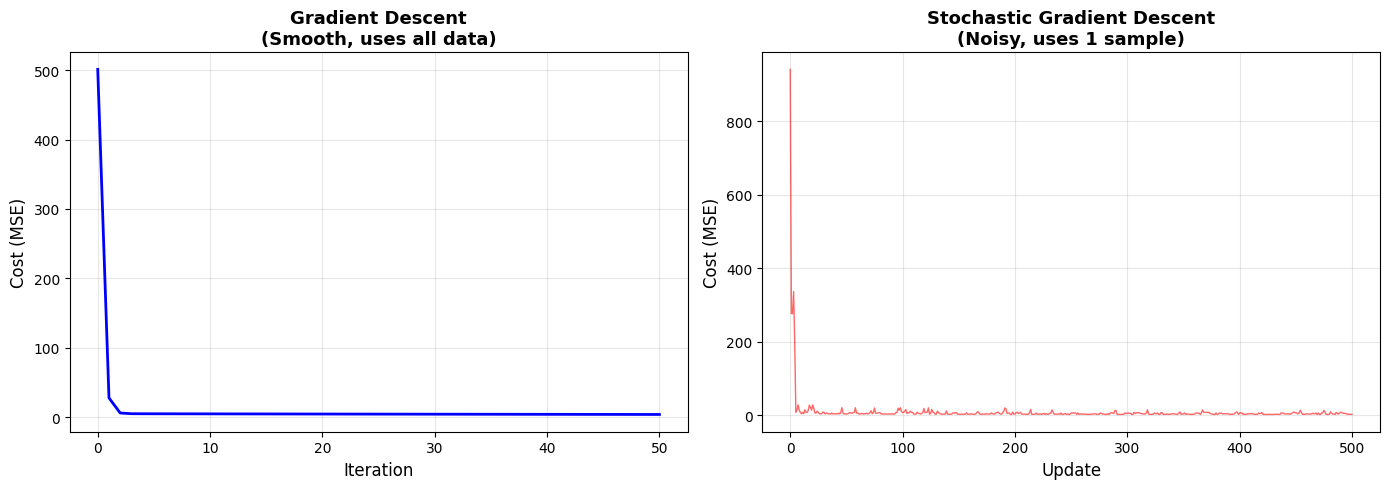

Key observation: SGD is noisier but makes MORE updates → faster learning


In [14]:
# Visualization: Cost convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GD convergence
axes[0].plot(cost_hist_gd, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost (MSE)', fontsize=12)
axes[0].set_title('Gradient Descent\n(Smooth, uses all data)', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Right: SGD convergence
axes[1].plot(cost_hist_sgd, 'r-', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Update', fontsize=12)
axes[1].set_ylabel('Cost (MSE)', fontsize=12)
axes[1].set_title('Stochastic Gradient Descent\n(Noisy, uses 1 sample)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observation: SGD is noisier but makes MORE updates → faster learning")

### Key Takeaways: GD vs SGD

| Method | Data per Update | Speed | Convergence | Best For |
|--------|----------------|-------|-------------|----------|
| **GD** | All samples | Slow | Smooth | Small datasets |
| **SGD** | 1 sample | Fast | Noisy | Large datasets, online learning |

**In practice:** Mini-batch GD (uses small batches) combines benefits of both!

---
## Part 3: Logistic Regression - Binary Classification

**Problem:** Predict **binary outcomes** (0 or 1, yes/no, spam/not spam)

**Key Difference from Linear Regression:**
- Linear: Predicts continuous values $\hat{y} \in (-\infty, \infty)$
- Logistic: Predicts probabilities $\hat{y} \in [0, 1]$

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Maps any value to range [0, 1]
- Interpreted as: $P(y=1 | x)$

### Model
$$\hat{y} = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

### Cost Function (Cross-Entropy)
$$J(\theta) = -\frac{1}{M} \sum_{i=1}^{M} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

**Why not MSE?** MSE is non-convex for logistic regression → many local minima

In [15]:
# Generate binary classification data
X_class, y_class = make_classification(
    n_samples=200, n_features=2, n_redundant=0, 
    n_informative=2, n_clusters_per_class=1, random_state=42)

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

def logistic_loss(X, y, theta):
    """Binary cross-entropy loss"""
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-7  # Prevent log(0)
    return -(1/m) * np.sum(y * np.log(h + epsilon) + (1-y) * np.log(1-h + epsilon))

def logistic_gradient_descent(X, y, learning_rate=0.1, n_iterations=100):
    """GD for logistic regression"""
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    
    for i in range(n_iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * X.T @ (h - y)
        theta = theta - learning_rate * gradient
        cost_history.append(logistic_loss(X, y, theta))
    
    return theta, np.array(cost_history)

print('✓ Logistic regression functions defined')

✓ Logistic regression functions defined


In [17]:
# Train logistic regression
theta_log, cost_hist_log = logistic_gradient_descent(
    X_class, y_class, learning_rate=0.5, n_iterations=200)

# Make predictions
y_pred = (sigmoid(X_class @ theta_log) >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_class)

print(f"Training accuracy: {accuracy:.1%}")
print(f"Initial cost: {cost_hist_log[0]:.3f}")
print(f"Final cost: {cost_hist_log[-1]:.3f}")

Training accuracy: 84.0%
Initial cost: 0.585
Final cost: 0.367


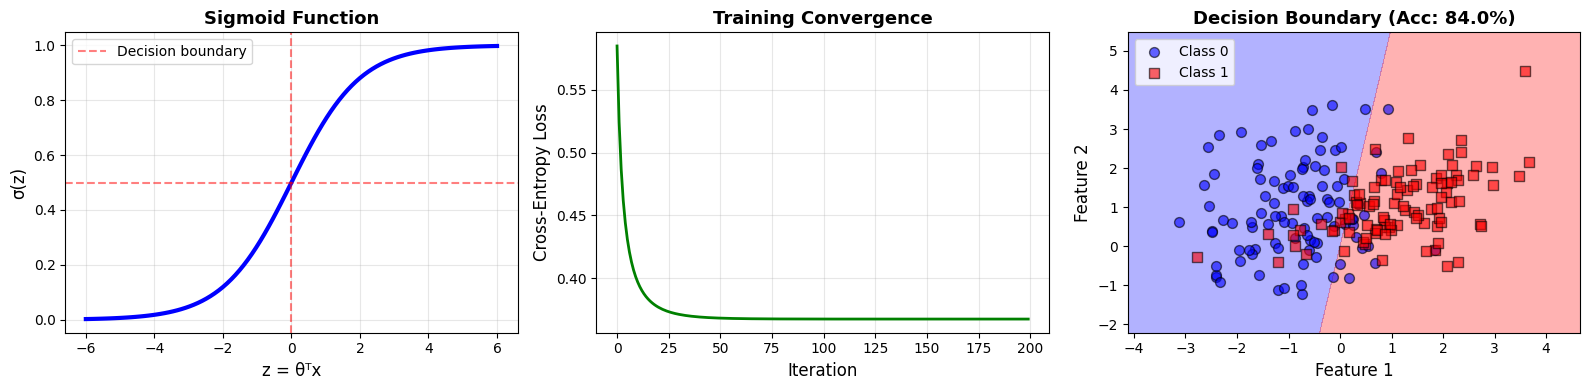

In [18]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Sigmoid function
z = np.linspace(-6, 6, 100)
axes[0].plot(z, sigmoid(z), 'b-', linewidth=3)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary')
axes[0].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('z = θᵀx', fontsize=12)
axes[0].set_ylabel('σ(z)', fontsize=12)
axes[0].set_title('Sigmoid Function', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Cost convergence
axes[1].plot(cost_hist_log, 'g-', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[1].set_title('Training Convergence', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

# 3. Decision boundary
h = 0.02
x_min, x_max = X_class[:, 0].min() - 1, X_class[:, 0].max() + 1
y_min, y_max = X_class[:, 1].min() - 1, X_class[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ theta_log)
Z = Z.reshape(xx.shape)

axes[2].contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
axes[2].scatter(X_class[y_class==0, 0], X_class[y_class==0, 1], 
                c='blue', marker='o', s=50, alpha=0.6, edgecolors='k', label='Class 0')
axes[2].scatter(X_class[y_class==1, 0], X_class[y_class==1, 1], 
                c='red', marker='s', s=50, alpha=0.6, edgecolors='k', label='Class 1')
axes[2].set_xlabel('Feature 1', fontsize=12)
axes[2].set_ylabel('Feature 2', fontsize=12)
axes[2].set_title(f'Decision Boundary (Acc: {accuracy:.1%})', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

### Key Takeaways: Logistic Regression

**Linear vs Logistic:**

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Task** | Continuous prediction | Binary classification |
| **Output** | $\hat{y} \in \mathbb{R}$ | $\hat{y} \in [0, 1]$ |
| **Activation** | None (identity) | Sigmoid |
| **Loss** | MSE | Cross-Entropy |
| **Decision** | N/A | Threshold at 0.5 |

**Important:** Despite its name, logistic regression is a **classification** algorithm!

---
## Summary

### 1. Linear Regression
- **Closed-form:** Fast for small datasets, exact solution
- **Use case:** Predicting house prices, temperatures, etc.

### 2. Gradient Descent Methods
- **GD:** Stable but slow (uses all data)
- **SGD:** Fast but noisy (uses 1 sample)
- **Why?** Scales to large datasets, works for non-linear models

### 3. Logistic Regression
- **Binary classification** using sigmoid function
- **Cross-entropy loss** instead of MSE
- **Use case:** Spam detection, disease diagnosis, etc.
